<a href="https://colab.research.google.com/github/Rohit4507/ML_revision_challenge/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Generate a strictly linearly separable classification dataset
X, y = make_classification(
    n_samples=250,          # Total number of data points
    n_features=2,           # 2D features for easy plotting
    n_informative=2,        # Both features carry useful information
    n_redundant=0,          # No useless/correlated linear combinations
    n_repeated=0,           # No duplicate features
    n_classes=2,            # Binary output (0 and 1)
    n_clusters_per_class=1, # Keep clusters unified
    class_sep=18,          # High value guarantees wide separation gap
    random_state=42,         # Ensures reproducibility
    hypercube=False
)

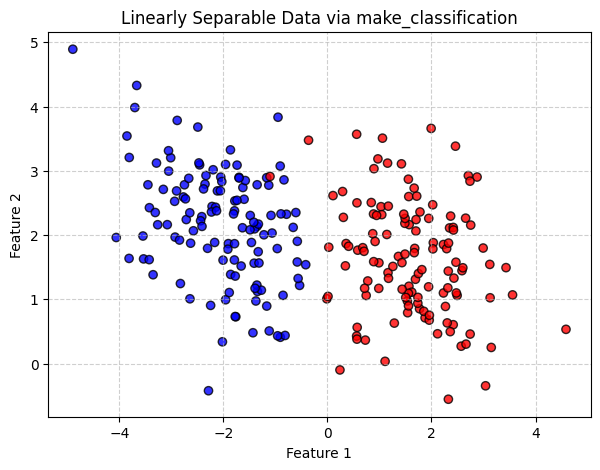

In [49]:
plt.figure(figsize=(7, 5))
# Plot class 0 points in blue, class 1 points in red
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8,)

plt.title("Linearly Separable Data via make_classification", fontsize=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [50]:
X

array([[-1.33116839,  1.74106597],
       [ 2.8768435 ,  2.90314953],
       [ 2.41787311,  0.60584592],
       [ 1.36465757,  1.66825944],
       [ 2.03510104,  1.88175422],
       [-1.63402433,  2.11399438],
       [ 1.70055228,  2.06319654],
       [ 1.16431397,  1.41507311],
       [-3.05216616,  2.99486041],
       [-2.21852743,  2.44531577],
       [ 3.12721955,  1.02455931],
       [-1.73779248,  3.08839609],
       [-1.12841544,  2.77626375],
       [ 0.98670698,  1.17099442],
       [-0.53528024,  1.21724891],
       [-4.06045289,  1.96253659],
       [ 1.28535307,  0.63085272],
       [ 2.65636887,  2.26309669],
       [ 1.05809692,  3.50777719],
       [ 2.74340849,  0.46025896],
       [ 0.98986275,  1.56871698],
       [-2.4574939 ,  3.09221288],
       [ 1.4227118 ,  3.10836995],
       [ 1.1078294 ,  0.03610424],
       [ 1.69168341,  1.31266179],
       [-0.90799346,  3.07374989],
       [-1.95885507,  3.0988703 ],
       [ 3.55853203,  1.06962874],
       [ 0.77513482,

In [51]:
y

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0])

In [52]:
def perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(1000):
    j = np.random.randint(0,100)
    y_pred = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_pred)*X[j]
  return weights[0], weights[1:]


In [53]:
def step(z):
  return 1 if z>0 else 0

In [54]:
intercept_, coef_ = perceptron (X,y)

In [55]:
print(intercept_)
print(coef_)

0.5000000000000001
[1.57732889 0.11949493]


In [56]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/ coef_[1])

In [61]:
X_input = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
y_input = m*X_input+b

(-2.0, 5.0)

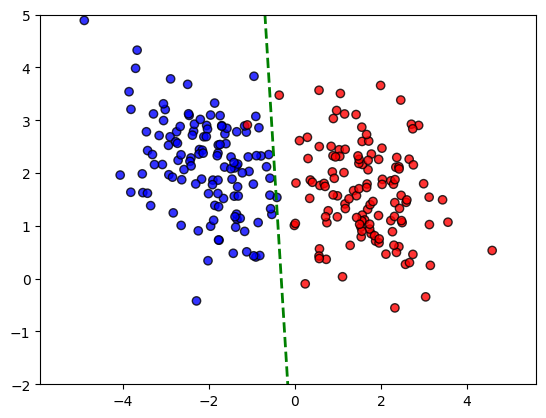

In [73]:
plt.plot(X_input, y_input, color='green', linestyle='--', linewidth=2, label='Decision Boundary')

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8,)
plt.ylim(-2,5)